### KVSWAP Throughput Evaluation

For **remote** throughput evaluation, this notebook is sufficient on its own.

On **your own device**, finish the setup steps in **README.md**, then run this notebook.

Run the cells **from top to bottom** to reproduce the throughput results.

Questions or problems? Please contact us.


### 1. Disk Setup

On our **remote** machine, keep the defaults below unchanged.

On **your own device**, set the paths and device names to match your eMMC/NVMe mounts and partitions. Set `MODEL_PATH_BASE_HF` and `MODEL_PATH_BASE` to your model weight directories, and `EVAL_LOG_DIR` to your preferred evaluation log directory.


In [4]:
# Adjust these values for your local device.
# On our remote machine, leave them unchanged.
#############################################################
EMMC_DEV_NAME='mmcblk0p1'
EMMC_OFFLOAD_DIR='/mnt/emmc/offload'
NVME_DEV_NAME='nvme0n1'
NVME_OFFLOAD_DIR='/mnt/nvme/offload'
MODEL_PATH_BASE_HF='../../ext_disk/model_weights_hf'
#############################################################
MODEL_PATH_BASE='../../ext_disk/model_weights'
EVAL_LOG_DIR='../../ext_disk/kvswap_logs'
#############################################################


### 2. User Config

#### Evaluation mode

Set `EVAL_MODE` to `'quick'` or `'full'`. Quick mode runs the full evaluation pipeline in about **xxx** hours; full mode takes about **xxx** hours.

- **Quick:** 2 repetitions per experiment (shorter runs); some baseline settings are omitted.
- **Full:** 5 repetitions per experiment (more stable statistics).

#### Set `EVAL_USER`

`EVAL_USER` is a short label that separates output folders when multiple people evaluate on the same machine. Results are written under `RESULTS/<EVAL_USER>/`.

**For artifact-evaluation (AE) reviewers:** choose a unique `EVAL_USER` so your results are not mixed with anyone else's.



In [5]:
# --- Edit before running ---
# Unique label; outputs go to RESULTS/<EVAL_USER>/
# For AE reviewers, please change this to a unique name.
EVAL_USER = 'test0'

# 'quick' (faster, fewer repetitions) or 'full' (complete evaluation)
# default to 'quick'
EVAL_MODE = 'quick'


### 3. Table 4

Run the cell below to generate Table 4.

Runtime: about **5** h (quick mode) and **15** h (full mode).

In **quick** mode, batch sizes **2** and **8** are skipped (only **1, 4, 16**); FlexGen and Loki are also omitted.


In [ ]:
%%bash -s "$EMMC_DEV_NAME" "$EMMC_OFFLOAD_DIR" "$NVME_DEV_NAME" "$NVME_OFFLOAD_DIR" "$MODEL_PATH_BASE_HF" "$MODEL_PATH_BASE" "$EVAL_LOG_DIR" "$EVAL_USER" "$EVAL_MODE"
export EMMC_DEV_NAME="$1"
export EMMC_OFFLOAD_DIR="$2"
export NVME_DEV_NAME="$3"
export NVME_OFFLOAD_DIR="$4"
export MODEL_PATH_BASE_HF="$5"
export MODEL_PATH_BASE="$6"
export EVAL_LOG_DIR="$7"
export EVAL_USER="$8"
EVAL_MODE="$9"

echo "Running Table 4 in ${EVAL_MODE} mode"
bash ./scripts/tab-4.sh $EVAL_MODE

echo "Finished running Table 4 in ${EVAL_MODE} mode"
echo "--------------------------------------------------------"
echo "Execute the next cell to show the results"


In [6]:
# Run this cell to show the results of Table 4
import html
from pathlib import Path
from IPython.display import HTML, display

if EVAL_MODE == "full":
    tab4_path = Path("./RESULTS/{}/tab-4-full.txt".format(EVAL_USER))
else:
    tab4_path = Path("./RESULTS/{}/tab-4.txt".format(EVAL_USER))

if tab4_path.is_file():
    text = tab4_path.read_text(encoding="utf-8")
    display(
        HTML(
            "<pre style='white-space:pre; font-family:monospace; line-height:1.2;'>"
            + html.escape(text)
            + "</pre>"
        )
    )
else:
    print("Table 4 file not found:", tab4_path.resolve())


### 4. Figure 10

Run the cell below to generate Figure 10.

Runtime: about **3** h (quick mode) and **7** h (full mode). 


In [ ]:
%%bash -s "$EMMC_DEV_NAME" "$EMMC_OFFLOAD_DIR" "$NVME_DEV_NAME" "$NVME_OFFLOAD_DIR" "$MODEL_PATH_BASE_HF" "$MODEL_PATH_BASE" "$EVAL_LOG_DIR" "$EVAL_USER" "$EVAL_MODE" 
export EMMC_DEV_NAME="$1"
export EMMC_OFFLOAD_DIR="$2"
export NVME_DEV_NAME="$3"
export NVME_OFFLOAD_DIR="$4"
export MODEL_PATH_BASE_HF="$5"
export MODEL_PATH_BASE="$6"
export EVAL_LOG_DIR="$7"
export EVAL_USER="$8"
EVAL_MODE="$9"

echo "Running Figure 10 in ${EVAL_MODE} mode"
bash ./scripts/fig-10.sh $EVAL_MODE

echo "Finished running Figure 10 in ${EVAL_MODE} mode"
echo "--------------------------------------------------------"
echo "Execute the next cell to show the results"


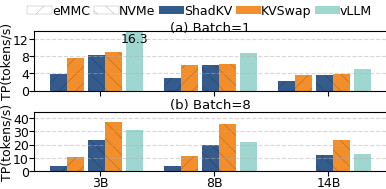

In [7]:
# Run this cell to show the results of Figure 10
from IPython.display import Image, display

if EVAL_MODE == 'full':
    # display results with enough experiments repetitions
    display(Image("./RESULTS/{}/fig-10-full.png".format(EVAL_USER), width=500, height=400))
else:
    # display results with less experiments repetitions for quicker evaluation
    display(Image("./RESULTS/{}/fig-10.png".format(EVAL_USER), width=500, height=400))


### 5. Figure 11 (throughput)

Run the cell below to generate the **throughput** part of Figure 11.

This notebook only covers throughput. For the **accuracy** part of Figure 11, see the quality evaluations in the repository's `quality/` directory.

In **quick** mode, **Loki** is omitted.

Runtime: about **2** h (quick mode) and **6** h (full mode). 



In [ ]:
%%bash -s "$EMMC_DEV_NAME" "$EMMC_OFFLOAD_DIR" "$NVME_DEV_NAME" "$NVME_OFFLOAD_DIR" "$MODEL_PATH_BASE_HF" "$MODEL_PATH_BASE" "$EVAL_LOG_DIR" "$EVAL_USER" "$EVAL_MODE"
export EMMC_DEV_NAME="$1"
export EMMC_OFFLOAD_DIR="$2"
export NVME_DEV_NAME="$3"
export NVME_OFFLOAD_DIR="$4"
export MODEL_PATH_BASE_HF="$5"
export MODEL_PATH_BASE="$6"
export EVAL_LOG_DIR="$7"
export EVAL_USER="$8"
EVAL_MODE="$9"

echo "Running Figure 11 (throughput) in ${EVAL_MODE} mode"
bash ./scripts/fig-11-tp.sh $EVAL_MODE

echo "Finished running Figure 11 (throughput) in ${EVAL_MODE} mode"
echo "--------------------------------------------------------"
echo "Execute the next cell to show the results"


In [ ]:
# Run this cell to show the results of Figure 11 (throughput)
from IPython.display import Image, display

if EVAL_MODE == 'full':
    # display results with enough experiments repetitions
    display(Image("./RESULTS/{}/fig-11-tp-full.png".format(EVAL_USER), width=500, height=400))
else:
    # display results with less experiments repetitions for quicker evaluation
    display(Image("./RESULTS/{}/fig-11-tp.png".format(EVAL_USER), width=500, height=400))
    

### Done

You have completed the throughput evaluation. Thank you for your time and effort!

If anything is unclear or you run into problems, please contact us.
